<span style="color:green; font-size:26px; font-weight:bold;">MODELO 1: </span>

<span style="color:green; font-size:33px; font-weight:bold;">REGRESION LINEAL_V1 (con variables demográficas)</span>

________________________________________________________________________________________________________________________________


### Justificación   

La Regresión Lineal se utiliza como modelo base de referencia para el problema de predicción de la satisfacción con la vida. Este algoritmo estima la relación lineal existente entre la variable objetivo y el conjunto de variables explicativas seleccionadas.

Su principal ventaja es la facilidad de interpretación de los resultados, ya que permite analizar la influencia de cada variable predictora sobre la satisfacción vital. Además, constituye un punto de partida adecuado para comparar posteriormente el rendimiento de modelos más complejos basados en árboles de decisión y técnicas de ensamblado.

Aunque la relación entre las variables puede no ser estrictamente lineal, la Regresión Lineal proporciona una primera aproximación al problema y permite establecer una línea base de rendimiento frente a la cual evaluar el resto de modelos.


In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
df_modelo = pd.read_csv("../1_Data/processed.csv", sep = ",")

df_modelo

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,48,6,3,1,1,1,1,3,8,8,9,8,5,9,6,8,3,8,6
1,48,6,6,1,1,1,3,3,9,9,10,9,6,9,10,8,4,8,2
2,48,1,1,1,1,3,1,2,8,8,9,8,8,9,8,9,4,6,3
3,48,1,4,1,1,1,1,1,9,9,9,7,7,10,5,10,4,5,4
4,48,6,6,1,1,3,3,3,8,8,10,8,8,9,10,9,3,7,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5279,1,1,4,1,1,2,1,3,7,9,8,7,8,9,8,8,4,6,6
5280,1,6,7,4,1,1,3,1,6,8,7,3,6,7,10,8,3,5,6
5281,1,6,3,5,1,2,3,2,4,5,5,5,5,8,5,7,3,5,5
5282,1,1,5,4,1,1,1,3,8,8,9,8,8,8,7,8,3,7,5


In [3]:
df_modelo.info()

<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   Terr_hist              5284 non-null   int64
 1   Sexo                   5284 non-null   int64
 2   Edad_interv            5284 non-null   int64
 3   Lugar_nacim            5284 non-null   int64
 4   Nacionalidad           5284 non-null   int64
 5   Nivel_estudios         5284 non-null   int64
 6   Actividad              5284 non-null   int64
 7   Tipo_hogar             5284 non-null   int64
 8   Target_Satisfacc_Vida  5284 non-null   int64
 9   Satisf_relac_pers      5284 non-null   int64
 10  Sentido_propia_vida    5284 non-null   int64
 11  Satisf_econom_domest   5284 non-null   int64
 12  Valor_Estado_animo     5284 non-null   int64
 13  Satisf_vivienda        5284 non-null   int64
 14  Satisf_tiempo_disp     5284 non-null   int64
 15  Satisf_viv_y_entorno   5284 non-null   int64
 16 

In [4]:
df_modelo.describe(include='all')

,Terr_hist,Sexo,Edad_interv,Lugar_nacim,Nacionalidad,Nivel_estudios,Actividad,Tipo_hogar,Target_Satisfacc_Vida,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
count,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000,5284.000000
mean,27.478236,3.649508,4.648940,1.975208,1.222369,1.950227,2.026495,2.322104,7.313588,7.793906,7.626041,6.989402,6.411052,7.609765,6.913134,7.322861,2.921840,6.453255,4.495458
std,19.050649,2.495762,1.814499,1.515505,1.030825,0.899861,0.979855,1.240506,1.770229,1.698033,1.803999,1.812392,1.477396,1.832021,2.235819,1.419637,0.767344,1.994762,2.048203
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,20.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,7.000000,7.000000,6.000000,5.000000,7.000000,6.000000,7.000000,3.000000,5.000000,3.000000
50%,20.000000,6.000000,5.000000,1.000000,1.000000,2.000000,2.000000,2.000000,8.000000,8.000000,8.000000,7.000000,7.000000,8.000000,7.000000,8.000000,3.000000,7.000000,5.000000
75%,48.000000,6.000000,6.000000,4.000000,1.000000,3.000000,3.000000,3.000000,8.000000,9.000000,9.000000,8.000000,7.000000,9.000000,8.000000,8.000000,3.000000,8.000000,6.000000
max,48.000000,6.000000,7.000000,5.000000,6.000000,3.000000,3.000000,5.000000,10.000000,10.000000,10.000000,10.000000,9.000000,10.000000,10.000000,10.000000,4.000000,10.000000,10.000000


In [5]:
#creo dataset para modelo eliminando variables demográficas:

df_modelo_reducido = df_modelo[[
    'Target_Satisfacc_Vida',
    'Satisf_relac_pers',
    'Sentido_propia_vida',
    'Satisf_econom_domest',
    'Valor_Estado_animo',
    'Satisf_vivienda',
    'Satisf_tiempo_disp',
    'Satisf_viv_y_entorno',
    'Salud_percibida',
    'Confianza_personas',
    'Confianza_poderes_pub'
]].copy()


In [6]:
# Separo X e y

X = df_modelo_reducido.drop(columns=['Target_Satisfacc_Vida'])

y = df_modelo_reducido['Target_Satisfacc_Vida']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (5284, 10)
Dimensiones de y: (5284,)


In [7]:
# Separo en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=10
)

In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4227, 10)
X_test: (1057, 10)
y_train: (4227,)
y_test: (1057,)


Con el objetivo de homogeneizar la escala de las variables predictoras, aplico una estandarización mediante StandardScaler. Esta transformación centra cada variable en media cero y desviación típica uno. El escalador se ajusta exclusivamente sobre el conjunto de entrenamiento y posteriormente se aplica al conjunto de prueba.

In [9]:
# Escalado

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4227, 10)
(1057, 10)


In [11]:

pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).head()

,Satisf_relac_pers,Sentido_propia_vida,Satisf_econom_domest,Valor_Estado_animo,Satisf_vivienda,Satisf_tiempo_disp,Satisf_viv_y_entorno,Salud_percibida,Confianza_personas,Confianza_poderes_pub
0,1.289451,0.205338,0.012558,1.746520,1.317433,-0.885645,1.891755,0.095529,-0.227972,0.732122
1,-2.211947,-2.560637,-1.629167,-2.331104,0.222938,-1.338266,-2.329492,-1.207056,-1.717364,-2.200760
2,0.122318,-0.901052,0.012558,1.066916,0.770185,-0.885645,1.188214,1.398114,-0.227972,0.243308
3,0.705885,-0.347857,0.012558,0.387312,0.222938,0.019595,0.484673,0.095529,1.261420,0.732122
4,1.289451,1.311728,0.559800,-0.971896,0.222938,1.377457,0.484673,-1.207056,-0.724436,-0.245505


In [12]:
from sklearn.linear_model import LinearRegression

# Creo y entreno el modelo
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [13]:
# Hago predicciones sobre el conjunto de test
y_pred_lr = lr.predict(X_test_scaled)

In [14]:
#metricas de evaluacion comparando proyecciones con real:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

print(f"R²   : {r2:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")

R²   : 0.594
MAE  : 0.783
MSE  : 1.261
RMSE : 1.123


In [ ]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr.coef_
})

coeficientes.sort_values(
    by='Coeficiente',
    ascending=False
)

,Variable,Coeficiente
0,Satisf_relac_pers,0.667376
1,Sentido_propia_vida,0.454949
2,Satisf_econom_domest,0.229148
7,Salud_percibida,0.219320
3,Valor_Estado_animo,0.199783
5,Satisf_tiempo_disp,0.128564
4,Satisf_vivienda,0.069887
9,Confianza_poderes_pub,0.032048
8,Confianza_personas,0.017742
6,Satisf_viv_y_entorno,-0.032928


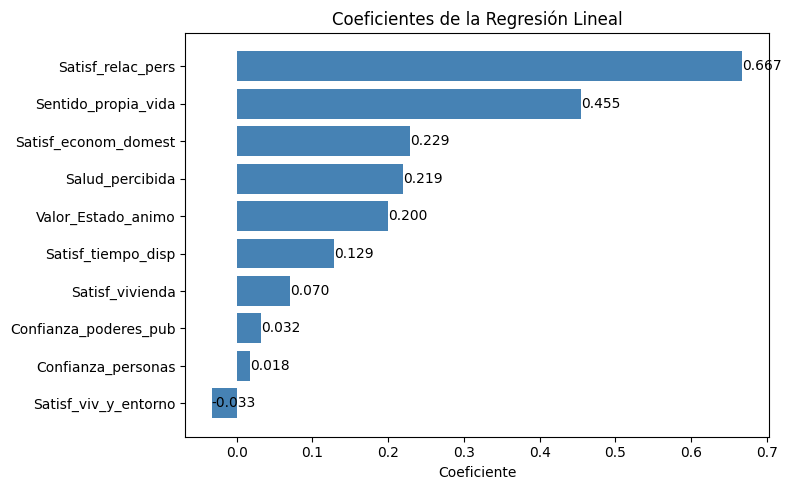

In [ ]:
coeficientes = coeficientes.sort_values(
    by='Coeficiente',
    ascending=True
)

plt.figure(figsize=(8, 5))

bars = plt.barh(
    coeficientes['Variable'],
    coeficientes['Coeficiente'],
    color='steelblue'
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():.3f}',
        va='center'
    )

plt.title('Coeficientes de la Regresión Lineal')
plt.xlabel('Coeficiente')

plt.tight_layout()
plt.show()

Comparamos dos versiones de un modelo de Regresión Lineal: una que incorpora variables demográficas y otra basada exclusivamente en variables de bienestar. Los resultados muestran una ligera mejora en todas las métricas de evaluación al excluir las variables demográficas (R² = 0,594 frente a 0,592; MAE = 0,783 frente a 0,785; MSE = 1,261 frente a 1,266; RMSE = 1,123 frente a 1,125). Por ello, decido construir el resto de modelos utilizando únicamente las variables de bienestar seleccionadas.

El segundo modelo de Regresión Lineal se desarrolló utilizando exclusivamente las variables de bienestar previamente seleccionadas, excluyendo todas las variables demográficas. Los resultados obtenidos fueron un coeficiente de determinación R² de 0,594, un error absoluto medio (MAE) de 0,783, un error cuadrático medio (MSE) de 1,261 y una raíz del error cuadrático medio (RMSE) de 1,123.

El modelo explica aproximadamente el 59,4% de la variabilidad de la satisfacción con la vida, alcanzando un rendimiento ligeramente superior al obtenido por el modelo que incorporaba variables demográficas. Asimismo, presenta valores inferiores en todas las métricas de error, lo que indica una mayor capacidad predictiva.

Aunque las diferencias son reducidas, los resultados muestran que las variables demográficas no contribuyen a mejorar la calidad de las predicciones. Por el contrario, el modelo basado únicamente en variables de bienestar logra un ajuste ligeramente mejor utilizando un conjunto de variables más reducido y directamente relacionado con el fenómeno estudiado. Por este motivo, utilizo esta configuración como modelo base para el resto del proyecto y para la comparación con los modelos de aprendizaje automático posteriores.